In [9]:
import qiskit
import phoenix
import json
from qiskit.quantum_info import Operator

**Load Pauli strings and coefficients from a JSON file and construct a `Hamiltonian` instance**

In [10]:
# with open("./hams/LiH_as_2e_4o_JW_sto3g.json", "r") as f:
# with open("./hams/BeH2_as_4e_4o_JW_sto3g.json", "r") as f:
with open("./uccsd/ucc_10e_7o_BK.json", "r") as f:
    data = json.load(f)

def get_weight(pauli):
    return len(pauli) - pauli.count("I")

M = -1 # the first M terms to keep (just for demonstration purposes)

sorted_pairs = sorted(zip(data["paulis"], data["coeffs"]), key=lambda x: -get_weight(x[0]))
paulis = [pair[0] for pair in sorted_pairs[:M]]
coeffs = [pair[1] for pair in sorted_pairs[:M]]

ham = phoenix.Hamiltonian(paulis, coeffs)
# ham = phoenix.Hamiltonian(['XXXZIYZI', 'YXXZIYYI', 'ZXXZIYZI'], [-0.0125, -0.0125, -0.0125])

# u = ham.unitary_evolution()

In [11]:
ham.print_tableau()  # BSF representation of the Pauli terms in the Hamiltonian

+--------------------------------------------------------------------------------+
|                             Qubit index: q0...q13                              |
+----------------+-----------------------------+-----------------------------+---+
|     Pauli      |            X part           |            Z part           | s |
+----------------+-----------------------------+-----------------------------+---+
| XXIXZYZYIIIZYX | 1 1 0 1 0 1 0 1 0 0 0 0 1 1 | 0 0 0 0 1 1 1 1 0 0 0 1 1 0 | 0 |
| YXIXZYZYIIIZXX | 1 1 0 1 0 1 0 1 0 0 0 0 1 1 | 1 0 0 0 1 1 1 1 0 0 0 1 0 0 | 0 |
| YXIXZYZYIIIZZX | 1 1 0 1 0 1 0 1 0 0 0 0 0 1 | 1 0 0 0 1 1 1 1 0 0 0 1 1 0 | 0 |
| XXIYZXIIXXIYYX | 1 1 0 1 0 1 0 0 1 1 0 1 1 1 | 0 0 0 1 1 0 0 0 0 0 0 1 1 0 | 0 |
| XXIYZXIIYXIYXX | 1 1 0 1 0 1 0 0 1 1 0 1 1 1 | 0 0 0 1 1 0 0 0 1 0 0 1 0 0 | 0 |
| YXIYZXIIXXIYXX | 1 1 0 1 0 1 0 0 1 1 0 1 1 1 | 1 0 0 1 1 0 0 0 0 0 0 1 0 0 | 0 |
| YXIYZXIIYXIYYX | 1 1 0 1 0 1 0 0 1 1 0 1 1 1 | 1 0 0 1 1 0 0 0 1 0 0 1 1 0 | 0 |
| XX

In [12]:
qc_trivial = ham.generate_circuit()
phoenix.utils.print_circ_info(qc_trivial, title="Trivial synthesized circuit")
print(qc_trivial.count_ops())
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_trivial).to_matrix()))

+----------------------------------------------------------+
|               Trivial synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     14     |   25229   |    13108     | 15705 |  12850   |
+------------+-----------+--------------+-------+----------+
OrderedDict({'cx': 13108, 'h': 5344, 'sx': 2889, 'sxdg': 2889, 'rz': 999})


In [13]:
# DAC'25 PHOENIX compilation
qc_phoenix = phoenix.compile_hamiltonian_simulation(ham, grouping='support')
phoenix.utils.print_circ_info(qc_phoenix, title="PHOENIX synthesized circuit")
print(qc_phoenix.count_ops())
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_phoenix).to_matrix()))

+----------------------------------------------------------+
|               PHOENIX synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     14     |    6958   |     2317     |  3806 |   1904   |
+------------+-----------+--------------+-------+----------+
OrderedDict({'u': 4641, 'cx': 2317})


In [14]:
# Latest PHOENIX compilation (with default grouping method "peel")
qc_phoenix = phoenix.compile_hamiltonian_simulation(ham)
phoenix.utils.print_circ_info(qc_phoenix, title="PHOENIX synthesized circuit")
print(qc_phoenix.count_ops())
# print('Infidelity', phoenix.utils.infidelity(u, Operator(qc_phoenix).to_matrix()))

+----------------------------------------------------------+
|               PHOENIX synthesized circuit                |
+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|     14     |    6750   |     2248     |  2498 |   1249   |
+------------+-----------+--------------+-------+----------+
OrderedDict({'u': 4502, 'cx': 2248})


In [15]:
qc_phoenix.draw(fold=-1)

global phase: 5.4086
          ┌───────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     ┌───────────────────┐                                                              ┌─────────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     ┌───────────────────┐                                                                                         ┌───────────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              ┌───────────────────┐                                                          ┌───────────────┐                                  ┌───────────────────┐         ┌─────────────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

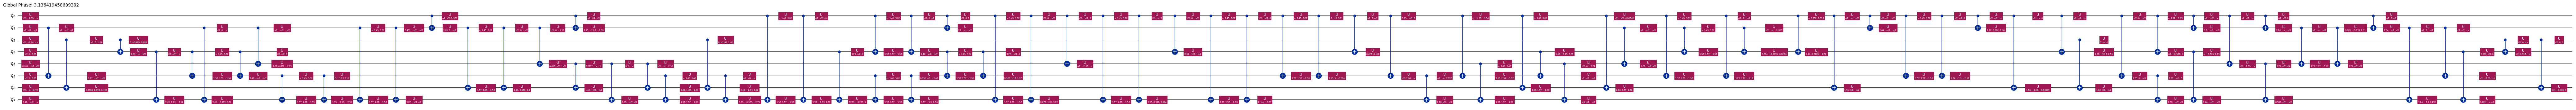

In [22]:
qc_phoenix.draw("mpl", fold=-1, scale=0.6)